> **Deep Learning Engineer View:** This notebook evaluates the final 7 models on the full dataset, presenting a comprehensive performance table, bar chart, and a grid of Confusion Matrices.

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class Autoformer(nn.Module):
    def __init__(self, c_in, c_out, seq_len):
        super().__init__()
        self.proj = nn.Linear(c_in, 64)
        # Simplified Auto-Correlation for short sequence
        self.fc_attn = nn.Linear(64, 64)
        self.fc1 = nn.Linear(64 * seq_len, 128)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, c_out)
        
    def forward(self, x):
        x = self.proj(x)
        # Simplified auto-correlation using FFT
        xf = torch.fft.rfft(x, dim=1)
        x_out = torch.fft.irfft(xf * torch.conj(xf), n=x.size(1), dim=1)
        x_out = self.fc_attn(x_out)
        x_out = x_out.reshape(x_out.size(0), -1)
        x_out = torch.relu(self.fc1(x_out))
        x_out = self.dropout(x_out)
        return self.fc2(x_out)


class Informer(nn.Module):
    def __init__(self, c_in, c_out, seq_len):
        super().__init__()
        self.proj = nn.Linear(c_in, 64)
        # Simplified ProbSparse Attention using standard MHA for short sequence (len 5)
        self.attn = nn.MultiheadAttention(embed_dim=64, num_heads=4, batch_first=True)
        self.fc1 = nn.Linear(64 * seq_len, 128)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, c_out)
        
    def forward(self, x):
        x = self.proj(x)
        x, _ = self.attn(x, x, x)
        x = x.reshape(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


class PatchTST(nn.Module):
    def __init__(self, c_in, c_out, seq_len):
        super().__init__()
        self.patch_proj = nn.Linear(c_in, 64)
        encoder_layer = nn.TransformerEncoderLayer(d_model=64, nhead=4, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc1 = nn.Linear(64 * seq_len, 128)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, c_out)
        
    def forward(self, x):
        # x: (batch, seq_len, c_in)
        x = self.patch_proj(x)
        x = self.transformer(x)
        x = x.reshape(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


class TimesNet(nn.Module):
    def __init__(self, c_in, c_out, seq_len):
        super().__init__()
        self.conv2d = nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1)
        self.fc1 = nn.Linear(32 * seq_len * c_in, 128)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, c_out)
        
    def forward(self, x):
        # x: (batch, seq_len, c_in)
        x = x.unsqueeze(1) # (batch, 1, seq_len, c_in)
        x = torch.relu(self.conv2d(x))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)




class TemporalFusionTransformer(nn.Module):
    def __init__(self, c_in, c_out, seq_len):
        super().__init__()
        self.lstm = nn.LSTM(c_in, 64, batch_first=True)
        self.attn = nn.MultiheadAttention(embed_dim=64, num_heads=4, batch_first=True)
        self.fc1 = nn.Linear(64, 32)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, c_out)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        attn_out, _ = self.attn(out, out, out)
        x = attn_out[:, -1, :]
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


In [3]:
import numpy as np
import joblib
import torch

# Load chronological test split datasets
X_3D = np.load("../dataset/X_test_3D.npy")
X_2D = np.load("../dataset/X_test_2D.npy")
y_test = np.load("../dataset/y_test.npy")

target_encoder = joblib.load("../models/target_encoder.pkl")
classes = target_encoder.classes_

X_3D_tensor = torch.tensor(X_3D, dtype=torch.float32)
print(f"Evaluated on hold-out chronological test set: {len(y_test)} samples")


Evaluated on hold-out chronological test set: 10027 samples


In [4]:
# Load all 7 models
lr = joblib.load("../models/logisticregression.pkl")
dt = joblib.load("../models/decisiontree.pkl")
rf = joblib.load("../models/randomforest.pkl")
xgb = joblib.load("../models/xgboost.pkl")
lstm_model = load_model("../models/lstm_model.keras")
gru_model = load_model("../models/gru_model.keras")
cnn_lstm_model = load_model("../models/cnn_lstm_model.keras")


In [5]:
# Load PyTorch Models
seq_len = X_3D_tensor.shape[1]
num_features = X_3D_tensor.shape[2]
num_classes = len(classes)

autoformer = Autoformer(c_in=num_features, c_out=num_classes, seq_len=seq_len)
autoformer.load_state_dict(torch.load('../models/autoformer_model.pth', weights_only=True))
autoformer.eval()

informer = Informer(c_in=num_features, c_out=num_classes, seq_len=seq_len)
informer.load_state_dict(torch.load('../models/informer_model.pth', weights_only=True))
informer.eval()

patchtst = PatchTST(c_in=num_features, c_out=num_classes, seq_len=seq_len)
patchtst.load_state_dict(torch.load('../models/patchtst_model.pth', weights_only=True))
patchtst.eval()

tft = TemporalFusionTransformer(c_in=num_features, c_out=num_classes, seq_len=seq_len)
tft.load_state_dict(torch.load('../models/tft_model.pth', weights_only=True))
tft.eval()

timesnet = TimesNet(c_in=num_features, c_out=num_classes, seq_len=seq_len)
timesnet.load_state_dict(torch.load('../models/timesnet_model.pth', weights_only=True))
timesnet.eval()


TimesNet(
  (conv2d): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4480, out_features=128, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)

In [6]:
# Generate predictions
preds = {}
preds["Logistic Regression"] = lr.predict(X_2D)
preds["Decision Tree"] = dt.predict(X_2D)
preds["Random Forest"] = rf.predict(X_2D)
preds["XGBoost"] = xgb.predict(X_2D)


preds["LSTM"] = np.argmax(lstm_model.predict(X_3D, verbose=0), axis=1)
preds["GRU"] = np.argmax(gru_model.predict(X_3D, verbose=0), axis=1)
preds["CNN-LSTM"] = np.argmax(cnn_lstm_model.predict(X_3D, verbose=0), axis=1)

# PyTorch Predictions
with torch.no_grad():
    preds['Autoformer'] = torch.argmax(autoformer(X_3D_tensor), dim=1).numpy()
    preds['Informer'] = torch.argmax(informer(X_3D_tensor), dim=1).numpy()
    preds['PatchTST'] = torch.argmax(patchtst(X_3D_tensor), dim=1).numpy()
    preds['TFT'] = torch.argmax(tft(X_3D_tensor), dim=1).numpy()
    preds['TimesNet'] = torch.argmax(timesnet(X_3D_tensor), dim=1).numpy()


In [7]:
# Create Performance Table
results = []
for name, y_pred in preds.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro F1 Score": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Weighted Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Weighted Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "Weighted F1 Score": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
display(results_df.style.format({
    "Accuracy": "{:.2%}",
    "Macro Precision": "{:.2%}", "Macro Recall": "{:.2%}", "Macro F1 Score": "{:.2%}",
    "Weighted Precision": "{:.2%}", "Weighted Recall": "{:.2%}", "Weighted F1 Score": "{:.2%}"
}))


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted Precision,Weighted Recall,Weighted F1 Score
8,Informer,87.86%,79.87%,80.61%,78.31%,91.20%,87.86%,88.81%
6,CNN-LSTM,87.64%,79.16%,79.15%,77.70%,90.30%,87.64%,88.43%
3,XGBoost,87.58%,77.78%,75.60%,76.23%,88.37%,87.58%,87.81%
2,Random Forest,87.38%,79.33%,79.97%,77.87%,90.61%,87.38%,88.34%
10,TFT,87.06%,78.72%,78.93%,77.21%,90.10%,87.06%,87.98%
5,GRU,87.05%,78.73%,79.45%,77.38%,90.27%,87.05%,88.03%
11,TimesNet,86.87%,78.00%,79.96%,77.16%,90.47%,86.87%,87.98%
4,LSTM,86.72%,78.08%,78.70%,76.88%,89.77%,86.72%,87.68%
0,Logistic Regression,86.59%,78.30%,79.87%,77.05%,90.57%,86.59%,87.80%
1,Decision Tree,86.30%,78.66%,79.74%,76.88%,90.59%,86.30%,87.56%


C:\Users\Hussain\AppData\Local\Temp\ipykernel_29292\2724157183.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=results_df, palette="viridis")


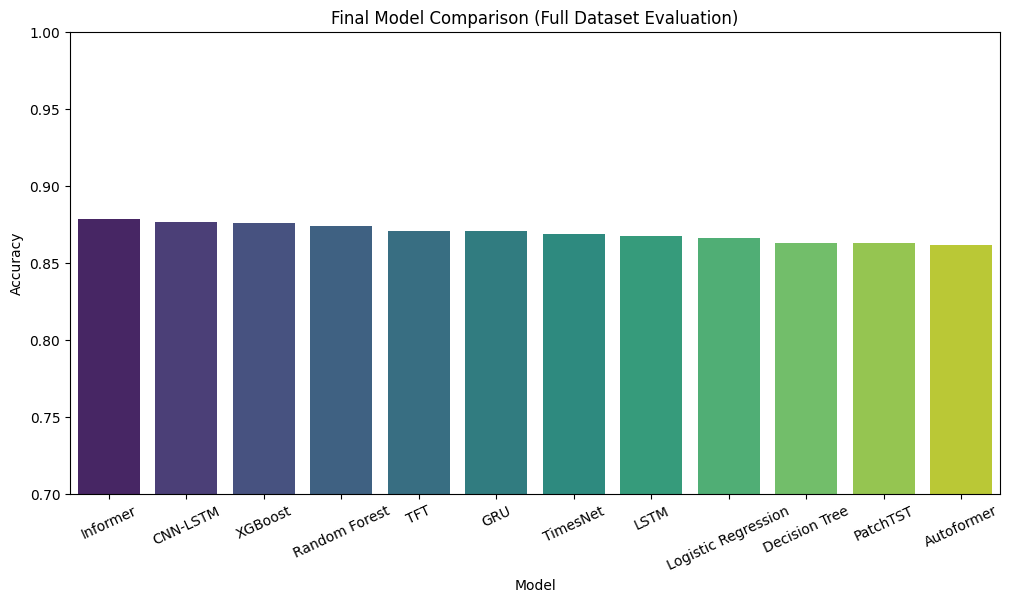

In [8]:
# Bar Chart Comparison
plt.figure(figsize=(12,6))
sns.barplot(x="Model", y="Accuracy", data=results_df, palette="viridis")
plt.ylabel("Accuracy")
plt.title("Final Model Comparison (Full Dataset Evaluation)")
plt.ylim(0.7, 1.0)
plt.xticks(rotation=25)
plt.show()


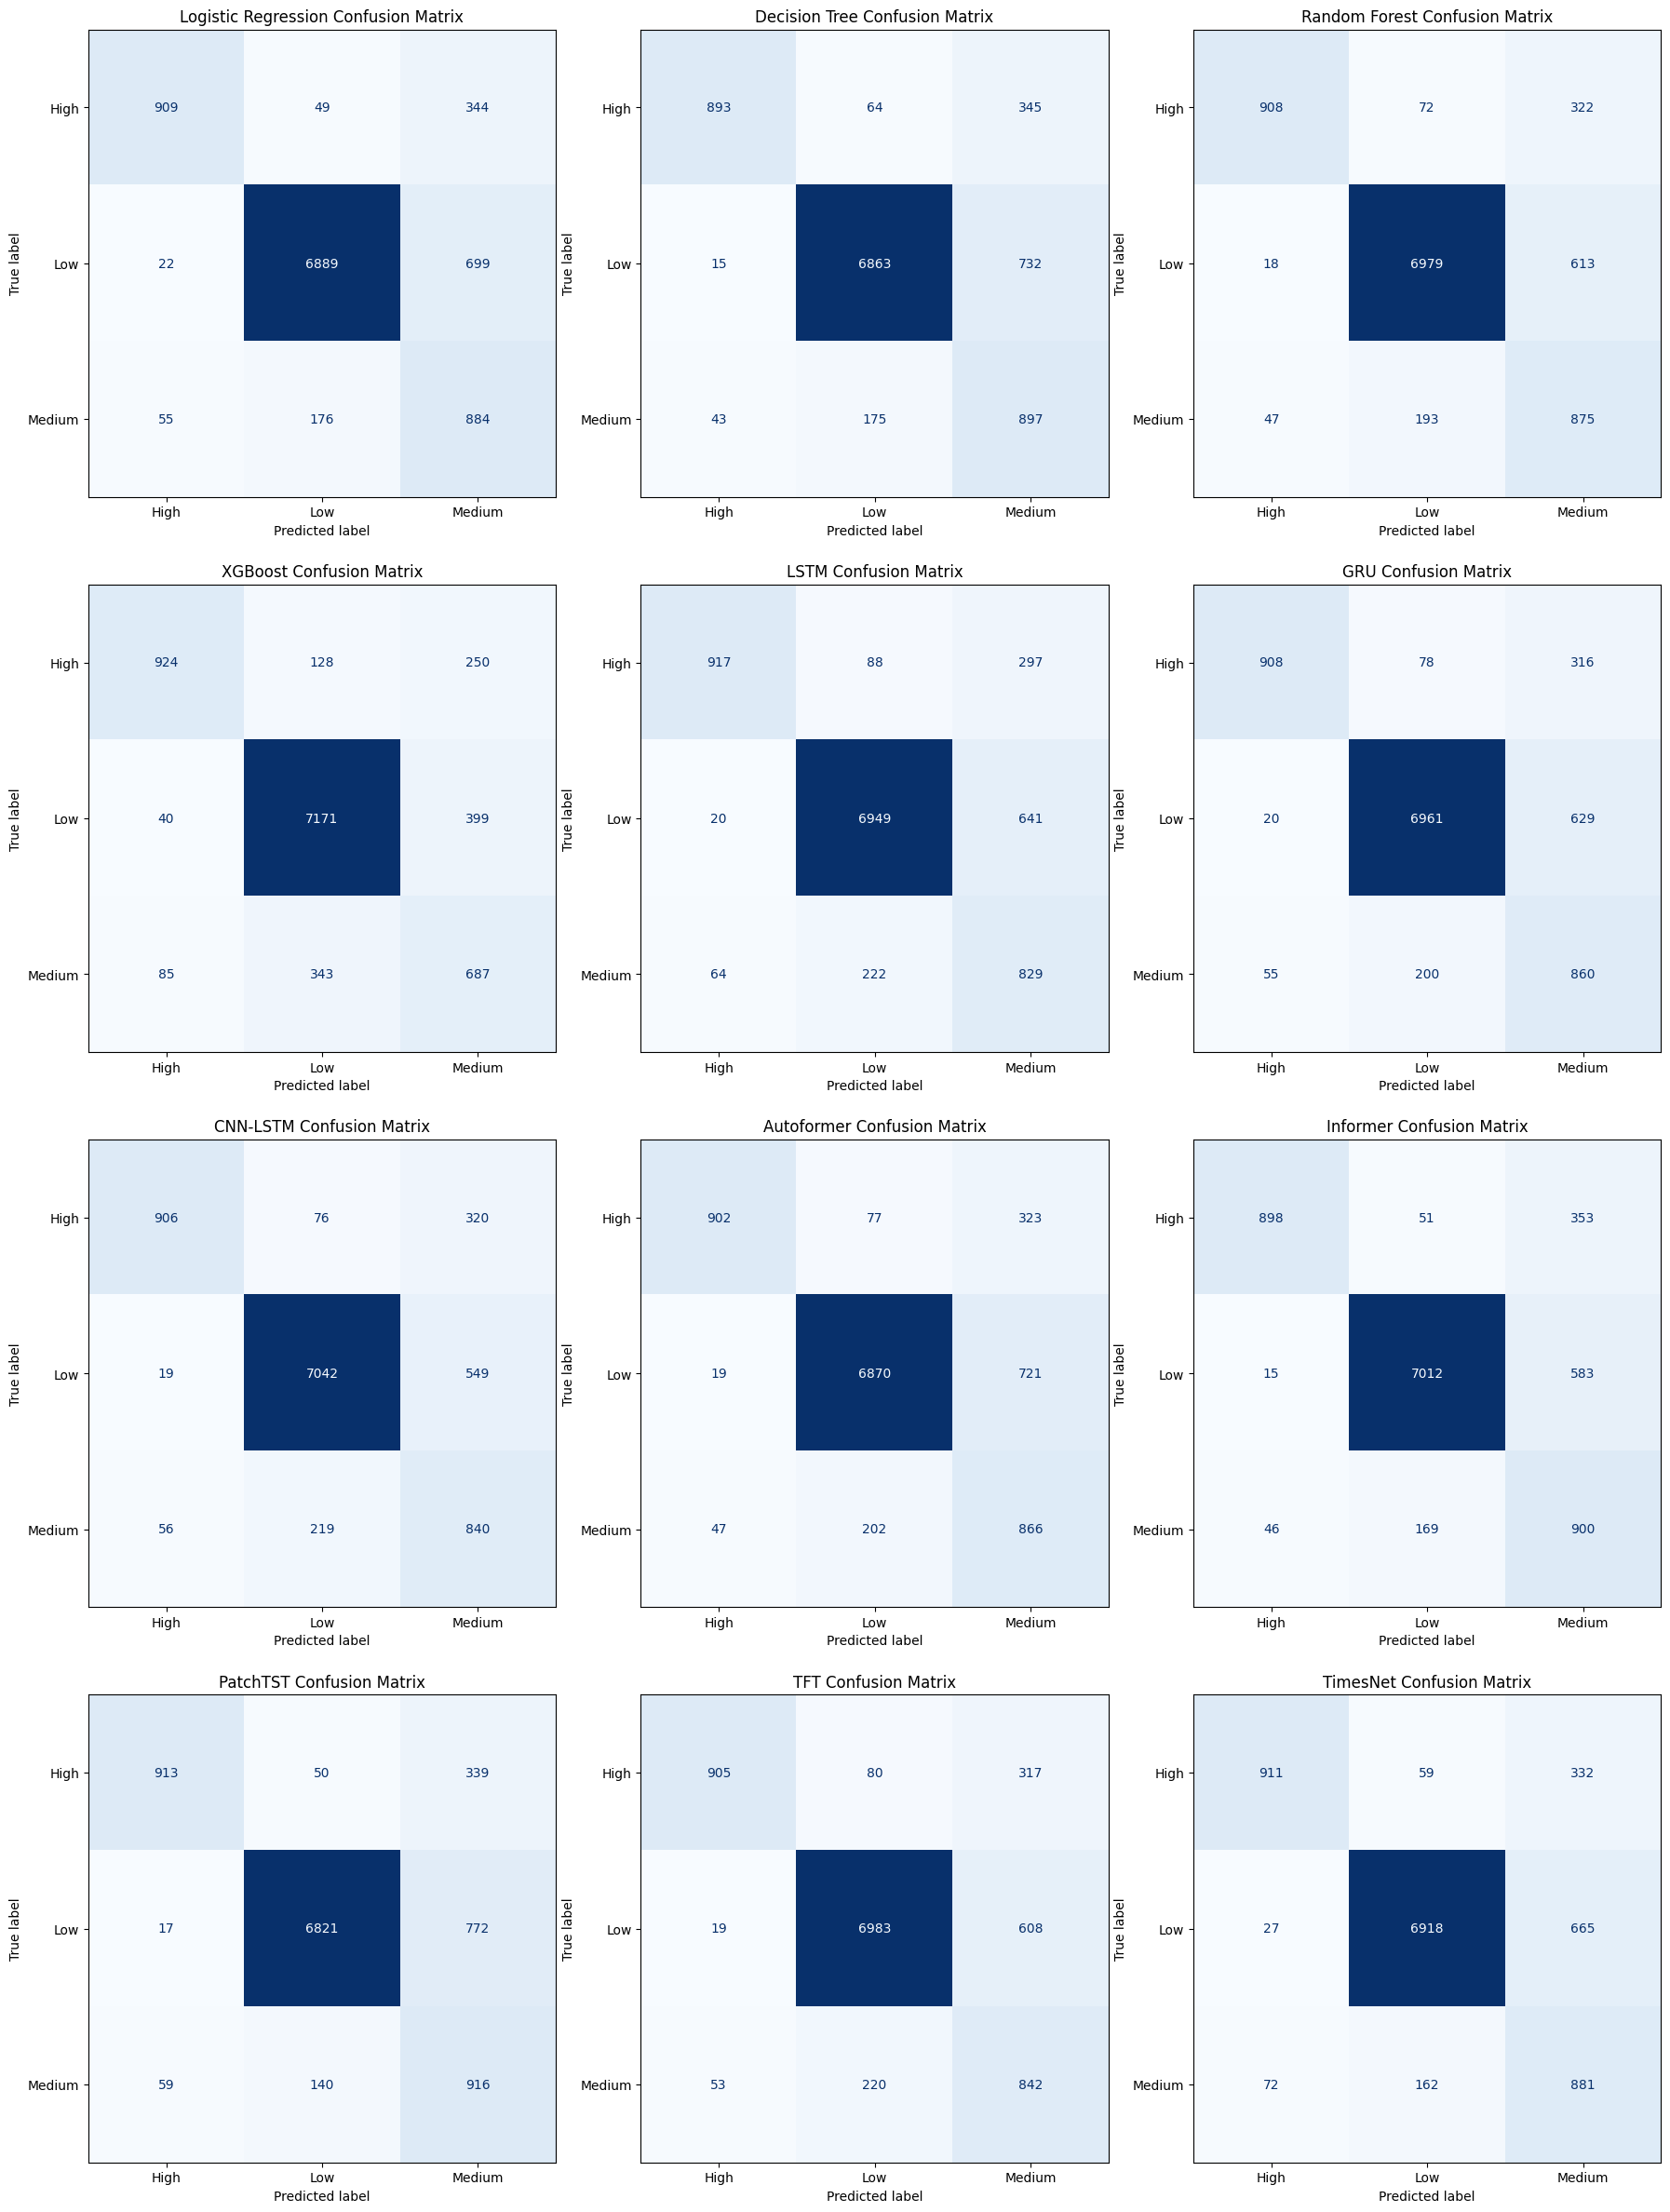

In [9]:
# Confusion Matrices Grid
fig, axes = plt.subplots(4, 3, figsize=(18, 24))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)
    axes[i].set_title(f"{name} Confusion Matrix")

# Hide empty subplots
for j in range(len(preds), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()


In [10]:
# Identify Best Model
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Accuracy']
print(f"Best Model: {best_model_name} with Accuracy {best_accuracy:.2%}")

# Save best model info for backend
import json
best_model_info = {
    'model_name': best_model_name,
    'accuracy': best_accuracy
}
with open('../models/best_model_info.json', 'w') as f:
    json.dump(best_model_info, f, indent=4)
print("Saved best_model_info.json successfully!")


Best Model: Informer with Accuracy 87.86%
Saved best_model_info.json successfully!
